## Step 1: Import libraries

- Load core data, plotting, and ML libraries
- Enable inline charts for notebook visuals

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Step 2: Load dataset

- Read the CSV into DataFrame `df`
- Use the local path `datasets/TS-PS12.csv`

In [2]:
df = pd.read_csv('datasets/TS-PS12.csv')

## Step 3: Dataset profiling

- Summarize shape, missing values, and unique counts
- Show numeric and categorical statistics
- Display the target distribution

In [3]:
from IPython.display import display

if "df" not in globals():
    df = pd.read_csv("datasets/TS-PS12.csv")

row_count, col_count = df.shape
cell_count = row_count * col_count
missing_total = int(df.isna().sum().sum())
missing_pct = round((missing_total / cell_count) * 100, 2) if cell_count else 0

overview = pd.DataFrame(
    [
        {
            "rows": row_count,
            "columns": col_count,
            "duplicate_rows": int(df.duplicated().sum()),
            "total_missing": missing_total,
            "missing_pct": missing_pct,
        }
    ]
)

display(overview)
display(df.head(5))

col_summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "nulls": df.isna().sum(),
        "null_pct": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(dropna=True),
        "unique_pct": (df.nunique(dropna=True) / row_count * 100).round(2),
    }
).sort_index()

display(col_summary)

numeric_cols = df.select_dtypes(include="number")
if not numeric_cols.empty:
    numeric_stats = numeric_cols.describe().T
    numeric_stats["median"] = numeric_cols.median()
    numeric_stats["range"] = numeric_cols.max() - numeric_cols.min()
    numeric_stats = numeric_stats[
        ["count", "mean", "std", "min", "25%", "50%", "75%", "max", "median", "range"]
    ]
    display(numeric_stats)

categorical_cols = df.select_dtypes(exclude="number")
if not categorical_cols.empty:
    cat_stats = pd.DataFrame(
        {
            "unique": categorical_cols.nunique(dropna=True),
            "top": categorical_cols.mode().iloc[0],
            "top_freq": categorical_cols.apply(
                lambda s: s.value_counts(dropna=False).iloc[0]
            ),
            "top_pct": (
                categorical_cols.apply(
                    lambda s: s.value_counts(dropna=False).iloc[0]
                )
                / row_count
                * 100
            ).round(2),
        }
    )
    display(cat_stats)

if "risk_label" in df.columns:
    risk_dist = pd.DataFrame(
        {
            "count": df["risk_label"].value_counts(dropna=False),
            "pct": (
                df["risk_label"].value_counts(normalize=True, dropna=False) * 100
            ).round(2),
        }
    )
    display(risk_dist)


,rows,columns,duplicate_rows,total_missing,missing_pct
0,50000,7,0,0,0.0


,student_id,attendance,marks,assignment,lms,risk_score,risk_label
0,1,84,96,34,20,28.8,Low
1,2,87,72,87,28,23.4,Low
2,3,93,87,95,26,15.1,Low
3,4,40,66,83,52,42.4,Medium
4,5,43,99,50,75,35.6,Medium


,dtype,non_null,nulls,null_pct,unique,unique_pct
assignment,int64,50000,0,0.0,70,0.14
attendance,int64,50000,0,0.0,60,0.12
lms,int64,50000,0,0.0,80,0.16
marks,int64,50000,0,0.0,70,0.14
risk_label,str,50000,0,0.0,3,0.01
risk_score,float64,50000,0,0.0,591,1.18
student_id,int64,50000,0,0.0,50000,100.00


,count,mean,std,min,25%,50%,75%,max,median,range
student_id,50000.0,25000.50000,14433.901067,1.0,12500.75,25000.5,37500.25,50000.0,25000.5,49999.0
attendance,50000.0,69.65930,17.312073,40.0,55.00,70.0,85.00,99.0,70.0,59.0
marks,50000.0,64.53546,20.216269,30.0,47.00,65.0,82.00,99.0,65.0,69.0
assignment,50000.0,64.45042,20.186077,30.0,47.00,65.0,82.00,99.0,65.0,69.0
lms,50000.0,59.35738,23.092708,20.0,39.00,59.0,79.00,99.0,59.0,79.0
risk_score,50000.0,33.94982,10.335702,3.2,26.60,34.0,41.20,65.2,34.0,62.0


,unique,top,top_freq,top_pct
risk_label,3,Medium,31990,63.98


,count,pct
risk_label,,
Medium,31990,63.98
Low,17899,35.80
High,111,0.22


# Dataset overview (TS-PS12.csv)

**Location:** datasets/TS-PS12.csv  
**Rows:** 50000  
**Columns:** 7  
**Missing values:** 0 (0.0%)  
**Duplicate rows:** 0  
**Targets:** risk_score (numeric), risk_label (class: Low, Medium, High)

## Use case

Predict a numeric risk score and classify students into Low, Medium, or High risk using engagement and performance signals.

## Feature dictionary

| feature | type | description | notes |
| --- | --- | --- | --- |
| assignment | int64 | Assignment performance score | 0-100 scale; 70 unique values |
| attendance | int64 | Attendance score | 0-100 scale; 60 unique values |
| lms | int64 | LMS engagement score | 0-100 scale; 80 unique values |
| marks | int64 | Exam/assessment marks | 0-100 scale; 70 unique values |
| risk_score | float64 | Composite risk score | Target for regression; 3.2-65.2 |
| student_id | int64 | Unique student identifier | Drop before modeling |
| risk_label | str | Risk class | Target for classification |

## Data quality and balance

- No missing values and no duplicate rows.
- Class imbalance: High is 0.22% of rows.

## Modeling notes

- Drop `student_id` before training.
- For classification, predict `risk_label` without using `risk_score` to avoid leakage.
- For regression, predict `risk_score` using the other features.
- Use class-weighted models or resampling to handle imbalance.

## Risk label distribution

| label | count | pct |
| --- | --- | --- |
| Medium | 31990 | 63.98 |
| Low | 17899 | 35.80 |
| High | 111 | 0.22 |

## Numeric feature summary

| feature | min | p25 | median | mean | p75 | max | std | range |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| student_id | 1.0 | 12500.75 | 25000.5 | 25000.5 | 37500.25 | 50000.0 | 14433.901067 | 49999.0 |
| attendance | 40.0 | 55.0 | 70.0 | 69.65930 | 85.0 | 99.0 | 17.312073 | 59.0 |
| marks | 30.0 | 47.0 | 65.0 | 64.53546 | 82.0 | 99.0 | 20.216269 | 69.0 |
| assignment | 30.0 | 47.0 | 65.0 | 64.45042 | 82.0 | 99.0 | 20.186077 | 69.0 |
| lms | 20.0 | 39.0 | 59.0 | 59.35738 | 79.0 | 99.0 | 23.092708 | 79.0 |
| risk_score | 3.2 | 26.6 | 34.0 | 33.94982 | 41.2 | 65.2 | 10.335702 | 62.0 |


## Step 4: Encode target labels

- Convert `risk_label` to numeric classes
- Store the encoder in `le` for reuse

In [4]:
# Label Encoding the Risk Labels

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['risk_label'] = le.fit_transform(df['risk_label'])

# Higher the number, higher the risk

## Step 5: Drop identifier

- Remove `student_id` to prevent leakage
- Keep only predictive features

In [5]:
df = df.drop("student_id", axis = 1)

## Step 6: Define features and targets

- Create classification features/target for `risk_label`
- Create regression features/target for `risk_score`

In [6]:
X_cls = df.drop(columns=["risk_label", "risk_score"])
y_cls = df["risk_label"]

X_reg = df.drop(columns=["risk_score", "risk_label"])
y_reg = df["risk_score"]

## Step 7: Train-test split

- Stratify the classification split for `risk_label`
- Use a standard split for the regression target

In [7]:
from sklearn.model_selection import train_test_split

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls,
    y_cls,
    test_size=0.3,
    random_state=42,
    stratify=y_cls,
)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.3,
    random_state=42,
)

## Step 8: Train and compare models

- Train classification models for `risk_label`
- Train regression models for `risk_score`
- Rank classifiers by F1-macro and regressors by RMSE

In [8]:
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
)

if "X_cls" not in globals() or "y_cls" not in globals():
    X_cls = df.drop(columns=["risk_label", "risk_score"])
    y_cls = df["risk_label"]

if "X_reg" not in globals() or "y_reg" not in globals():
    X_reg = df.drop(columns=["risk_score", "risk_label"])
    y_reg = df["risk_score"]

if y_cls.dtype == "object" or str(y_cls.dtype).startswith("category"):
    from sklearn.preprocessing import LabelEncoder

    le = LabelEncoder()
    y_cls = le.fit_transform(y_cls)

if "X_cls_train" not in globals():
    from sklearn.model_selection import train_test_split

    X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
        X_cls,
        y_cls,
        test_size=0.3,
        random_state=42,
        stratify=y_cls,
    )

if "X_reg_train" not in globals():
    from sklearn.model_selection import train_test_split

    X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
        X_reg,
        y_reg,
        test_size=0.3,
        random_state=42,
    )

try:
    from xgboost import XGBClassifier, XGBRegressor

    xgb_available = True
except Exception as exc:
    xgb_available = False
    print(f"XGBoost not available: {exc}")


def evaluate_classifier(name, model):
    model.fit(X_cls_train, y_cls_train)
    preds = model.predict(X_cls_test)
    return {
        "model": name,
        "accuracy": accuracy_score(y_cls_test, preds),
        "balanced_accuracy": balanced_accuracy_score(y_cls_test, preds),
        "f1_macro": f1_score(y_cls_test, preds, average="macro"),
        "f1_weighted": f1_score(y_cls_test, preds, average="weighted"),
    }, preds, model


def evaluate_regressor(name, model):
    model.fit(X_reg_train, y_reg_train)
    preds = model.predict(X_reg_test)
    rmse = float(np.sqrt(mean_squared_error(y_reg_test, preds)))
    return {
        "model": name,
        "mae": mean_absolute_error(y_reg_test, preds),
        "rmse": rmse,
        "r2": r2_score(y_reg_test, preds),
    }, preds, model


cls_models = []

log_reg = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                solver="lbfgs",
            ),
        ),
    ]
)
cls_models.append(("Logistic Regression", log_reg))

cls_models.append(
    (
        "Random Forest",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
        ),
    )
)

cls_models.append(
    (
        "Extra Trees",
        ExtraTreesClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
        ),
    )
)

cls_models.append(
    (
        "Gradient Boosting",
        GradientBoostingClassifier(random_state=42),
    )
)

cls_models.append(
    (
        "AdaBoost",
        AdaBoostClassifier(
            n_estimators=300,
            learning_rate=0.05,
            random_state=42,
        ),
    )
)

if xgb_available:
    num_classes = len(np.unique(y_cls))
    xgb_cls = XGBClassifier(
        objective="multi:softprob",
        num_class=num_classes,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss",
        tree_method="hist",
    )
    cls_models.append(("XGBoost Classifier", xgb_cls))

results_cls = []
preds_cls_map = {}
fitted_cls_models = {}

for name, model in cls_models:
    metrics, preds, fitted = evaluate_classifier(name, model)
    results_cls.append(metrics)
    preds_cls_map[name] = preds
    fitted_cls_models[name] = fitted

results_cls_df = (
    pd.DataFrame(results_cls)
    .set_index("model")
    .sort_values("f1_macro", ascending=False)
)

reg_models = []

lin_reg = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]
)
reg_models.append(("Linear Regression", lin_reg))

reg_models.append(
    (
        "Random Forest Regressor",
        RandomForestRegressor(
            n_estimators=300,
            random_state=42,
        ),
    )
)

reg_models.append(
    (
        "Extra Trees Regressor",
        ExtraTreesRegressor(
            n_estimators=300,
            random_state=42,
        ),
    )
)

reg_models.append(
    (
        "Gradient Boosting Regressor",
        GradientBoostingRegressor(random_state=42),
    )
)

if xgb_available:
    xgb_reg = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )
    reg_models.append(("XGBoost Regressor", xgb_reg))

results_reg = []
preds_reg_map = {}
fitted_reg_models = {}

for name, model in reg_models:
    metrics, preds, fitted = evaluate_regressor(name, model)
    results_reg.append(metrics)
    preds_reg_map[name] = preds
    fitted_reg_models[name] = fitted

results_reg_df = (
    pd.DataFrame(results_reg)
    .set_index("model")
    .sort_values("rmse", ascending=True)
)

display(results_cls_df)
display(results_reg_df)

,accuracy,balanced_accuracy,f1_macro,f1_weighted
model,,,,
XGBoost Classifier,0.988067,0.900562,0.925035,0.988023
Extra Trees,0.983600,0.897332,0.921789,0.983555
Random Forest,0.980933,0.884892,0.904625,0.980874
Gradient Boosting,0.979467,0.873324,0.831737,0.979669
Logistic Regression,0.990600,0.995103,0.829797,0.991658
AdaBoost,0.931667,0.614112,0.617428,0.930149


,mae,rmse,r2
model,,,
Linear Regression,1.958507e-14,2.371403e-14,1.000000
XGBoost Regressor,2.384766e-01,3.002842e-01,0.999155
Extra Trees Regressor,2.348392e-01,3.190115e-01,0.999046
Random Forest Regressor,3.709578e-01,4.792698e-01,0.997848
Gradient Boosting Regressor,3.841599e-01,4.821563e-01,0.997822


## Step 9: Best model report

- Show the top classifier for `risk_label`
- Show the top regressor for `risk_score`
- Include classification report, confusion matrix, and regression metrics

Best classification model by F1-macro: XGBoost Classifier
Classification metrics:
accuracy             0.988067
balanced_accuracy    0.900562
f1_macro             0.925035
f1_weighted          0.988023
Name: XGBoost Classifier, dtype: float64

Model type: XGBClassifier
Model params: {'objective': 'multi:softprob', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.9, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'mlogloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.08, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 4, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 300, 'n_jobs': -1, 'num_parallel_tree':

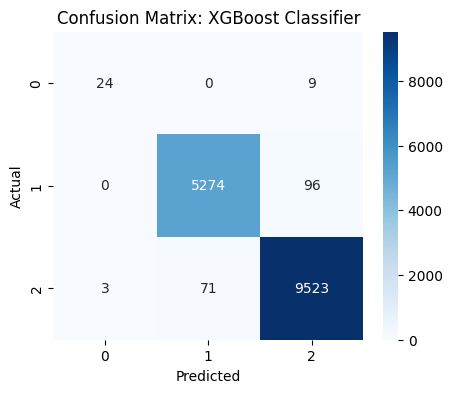


Best regression model by RMSE: Linear Regression
Regression metrics:
mae     1.958507e-14
rmse    2.371403e-14
r2      1.000000e+00
Name: Linear Regression, dtype: float64


In [9]:
from sklearn.metrics import classification_report, confusion_matrix

best_cls_name = results_cls_df.index[0]
best_cls_model = fitted_cls_models[best_cls_name]
best_cls_preds = preds_cls_map[best_cls_name]

print(f"Best classification model by F1-macro: {best_cls_name}")
print("Classification metrics:")
print(results_cls_df.loc[best_cls_name])

print("\nModel type:", type(best_cls_model).__name__)
try:
    print("Model params:", best_cls_model.get_params())
except Exception:
    print("Model params: unavailable")

print("\nClassification report:")
print(classification_report(y_cls_test, best_cls_preds, digits=4))

cm = confusion_matrix(y_cls_test, best_cls_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_cls_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

best_reg_name = results_reg_df.index[0]
best_reg_model = fitted_reg_models[best_reg_name]
reg_preds = best_reg_model.predict(X_reg_test)

print(f"\nBest regression model by RMSE: {best_reg_name}")
print("Regression metrics:")
print(results_reg_df.loc[best_reg_name])

## Step 10: Export best models

- Save `best_model_classification.pkl`
- Save `best_model_regression.pkl`
- Save `label_encoder.pkl` when available
- Provide download links

In [10]:
import joblib
from IPython.display import FileLink, display

if "results_cls_df" not in globals() or "fitted_cls_models" not in globals():
    raise RuntimeError("Run the modeling cell to train models before exporting.")

if "results_reg_df" not in globals() or "fitted_reg_models" not in globals():
    raise RuntimeError("Run the modeling cell to train models before exporting.")

best_cls_name = results_cls_df.index[0]
best_cls_model = fitted_cls_models[best_cls_name]

best_reg_name = results_reg_df.index[0]
best_reg_model = fitted_reg_models[best_reg_name]

cls_path = "best_model_classification.pkl"
reg_path = "best_model_regression.pkl"

joblib.dump(best_cls_model, cls_path)
joblib.dump(best_reg_model, reg_path)

encoder_path = None
if "le" in globals():
    encoder_path = "label_encoder.pkl"
    joblib.dump(le, encoder_path)

print(f"Saved classification model to {cls_path}")
display(FileLink(cls_path))

print(f"Saved regression model to {reg_path}")
display(FileLink(reg_path))

if encoder_path:
    print(f"Saved label encoder to {encoder_path}")
    display(FileLink(encoder_path))

Saved classification model to best_model_classification.pkl


c:\Users\Yashesh Mehta\Desktop\Tark Shastra 2026\ml application\best_model_classification.pkl

Saved regression model to best_model_regression.pkl


c:\Users\Yashesh Mehta\Desktop\Tark Shastra 2026\ml application\best_model_regression.pkl

Saved label encoder to label_encoder.pkl


c:\Users\Yashesh Mehta\Desktop\Tark Shastra 2026\ml application\label_encoder.pkl

## Step 11: Optional scratch cell

- Use this space for extra checks or experiments

## Conclusion and system summary

### System summary

- Goal: predict numeric `risk_score` and classify `risk_label` (Low, Medium, High).
- Data: 50,000 rows, 7 columns, no missing values; strong class imbalance for the High class.
- Pipeline: label encoding, feature selection (drop `student_id`), separate train/test splits for classification and regression, model comparison, best-model report, and export.
- Deployment path: exported `.pkl` models can be served by the ML API and consumed by the Core API.

### Model summary

- Classification: Logistic Regression baseline plus ensemble classifiers (RF, Extra Trees, GB, AdaBoost, XGBoost).
- Regression: Linear Regression baseline plus ensemble regressors (RF, Extra Trees, GB, XGBoost).
- Selection: best classifier by F1-macro; best regressor by RMSE.
- Outputs: classification report, confusion matrix, and downloadable model artifacts.